In [2]:
# logistic regression / binary classification

 Z  tensor([0., 0., 0., 0.])
 P  tensor([0.5000, 0.5000, 0.5000, 0.5000])
 DZ  tensor([ 0.5000,  0.5000, -0.5000, -0.5000])
 DW  tensor([-0.4625, -0.4625])
 DB  tensor(0.)
 w  tensor([0.2312, 0.2313])
 b  tensor(0.)
 epoch / loss  0 tensor(0.6931)
----------------------------------------
 Z  tensor([0.4856, 0.4856, 1.3412, 1.3412])
 P  tensor([0.6191, 0.6191, 0.7927, 0.7927])
 DZ  tensor([ 0.6191,  0.6191, -0.2073, -0.2073])
 DW  tensor([0.0347, 0.0141])
 DB  tensor(0.2059)
 w  tensor([0.2139, 0.2242])
 b  tensor(-0.1029)
 epoch / loss  1 tensor(0.5987)
----------------------------------------
 Z  tensor([0.3576, 0.3555, 1.1685, 1.1654])
 P  tensor([0.5884, 0.5879, 0.7629, 0.7623])
 DZ  tensor([ 0.5884,  0.5879, -0.2371, -0.2377])
 DW  tensor([-0.0267, -0.0442])
 DB  tensor(0.1754)
 w  tensor([0.2272, 0.2463])
 b  tensor(-0.1906)
 epoch / loss  2 tensor(0.5791)
----------------------------------------
 Z  tensor([0.3075, 0.3037, 1.1844, 1.1787])
 P  tensor([0.5763, 0.5753, 0.7657, 0.76

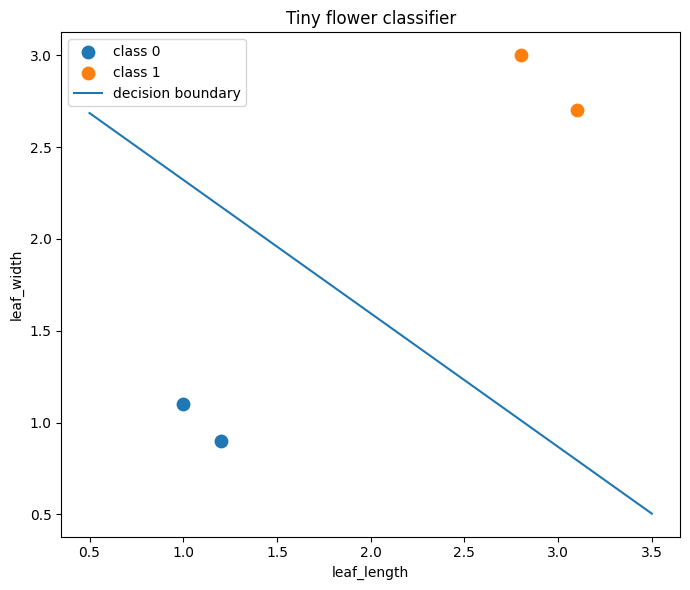

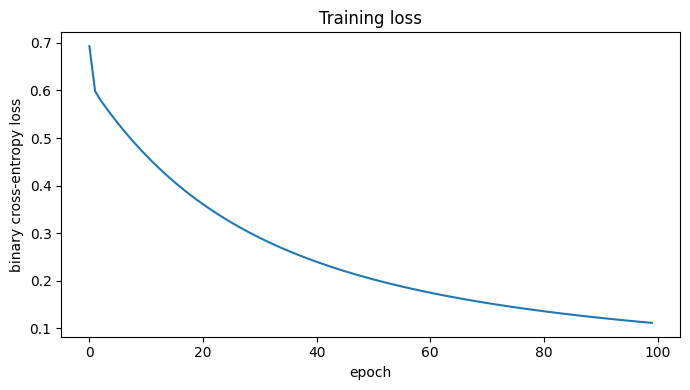

In [3]:
import torch
import matplotlib.pyplot as plt

# -----------------------------
# Tiny fake flower dataset
# -----------------------------
X = torch.tensor([
    [1.0, 1.1],   # class 0
    [1.2, 0.9],   # class 0
    [2.8, 3.0],   # class 1
    [3.1, 2.7],   # class 1
], dtype=torch.float32)

y = torch.tensor([0., 0., 1., 1.], dtype=torch.float32)

# -----------------------------
# One-neuron binary classifier:
# z = Xw + b
# p = sigmoid(z)
# -----------------------------
w = torch.zeros(2)
b = torch.tensor(0.0)

lr = 0.5
loss_history = []

def sigmoid(z):
    return 1 / (1 + torch.exp(-z))

# -----------------------------
# Training loop with manual backprop
# -----------------------------
for epoch in range(100): # 2000
    z = X @ w + b
    p = sigmoid(z)
    
    print( " Z " , z)
    print( " P " , p)
    
    #eps = 1e-8
    eps = 0
    loss = -(y * torch.log(p + eps) + (1 - y) * torch.log(1 - p + eps)).mean()
    loss_history.append(loss.item())

    # Chain rule:
    # dL/dz = p - y
    dz = p - y

    print( " DZ " , dz )

    # Batch gradients
    dw = (X.T @ dz) / len(X)
    db = dz.mean()

    print( " DW ", dw )
    print( " DB ", db )

    # Gradient descent update
    w -= lr * dw
    b -= lr * db

    print( " w " , w )
    print( " b " , b )

    print(" epoch / loss ", epoch, loss )
    print( 40 * '-')
    

    #break

print( " before prediction " )
print(X)
print(w)
print(b)
print(p)
print(sigmoid(X @ w + b))
print( " dw, db, dz " )
print(dw)
print(db)
print(dz)

# -----------------------------
# Predictions
# -----------------------------
with torch.no_grad():
    z = X @ w + b
    p = sigmoid(z)
    pred = (p >= 0.5).float()

print("Final parameters:")
print("w =", w)
print("b =", b)
print("\nPredictions:")
for i in range(len(X)):
    print(f"x={X[i].tolist()}  y={int(y[i].item())}  p={p[i].item():.4f}  pred={int(pred[i].item())}")

print( " \n final loss ", loss )
print(p)
print(w)
print(X)
print(b)
print(dw)
print(db)
print(dz)

# -----------------------------
# Plot 1: data + decision boundary
# z = w1*x1 + w2*x2 + b = 0
# => x2 = -(w1*x1 + b)/w2
# -----------------------------
plt.figure(figsize=(7, 6))

class0 = y == 0
class1 = y == 1

plt.scatter(X[class0, 0], X[class0, 1], label="class 0", s=80)
plt.scatter(X[class1, 0], X[class1, 1], label="class 1", s=80)

x_line = torch.linspace(0.5, 3.5, 100)
if abs(w[1].item()) > 1e-8:
    y_line = -(w[0] * x_line + b) / w[1]
    plt.plot(x_line.numpy(), y_line.numpy(), label="decision boundary")

plt.xlabel("leaf_length")
plt.ylabel("leaf_width")
plt.title("Tiny flower classifier")
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# Plot 2: training loss
# -----------------------------
plt.figure(figsize=(7, 4))
plt.plot(loss_history)
plt.xlabel("epoch")
plt.ylabel("binary cross-entropy loss")
plt.title("Training loss")
plt.tight_layout()
plt.show()

In [7]:
# using pytorch API with loss.backward()

In [5]:
import torch

# tiny dataset
X = torch.tensor([
    [1.0, 1.1],
    [1.2, 0.9],
    [2.8, 3.0],
    [3.1, 2.7],
], dtype=torch.float32)

y = torch.tensor([0., 0., 1., 1.], dtype=torch.float32).view(-1, 1)

# parameters
w = torch.zeros((2, 1), requires_grad=True)
b = torch.zeros(1, requires_grad=True)
print(w)
print(b)

lr = 0.5
loss_fn = torch.nn.BCELoss()

for epoch in range(100):
    # forward
    z = X @ w + b
    p = torch.sigmoid(z)          # BCELoss expects probabilities
    loss = loss_fn(p, y)

    # backward
    loss.backward()

    # gradient descent step
    with torch.no_grad():
        w -= lr * w.grad
        b -= lr * b.grad

    print(epoch, w.grad, b.grad)
    
    # clear gradients
    w.grad.zero_()
    b.grad.zero_()

    if epoch % 10 == 0:
        print(epoch, loss.item())

# predictions
with torch.no_grad():
    p = torch.sigmoid(X @ w + b)
    pred = (p >= 0.5).float()

print("w:", w.squeeze())
print("b:", b.item())
print("p:", p.squeeze())
print("pred:", pred.squeeze())
print(loss)

tensor([[0.],
        [0.]], requires_grad=True)
tensor([0.], requires_grad=True)
0 tensor([[-0.4625],
        [-0.4625]]) tensor([0.])
0 0.6931471824645996
1 tensor([[0.0347],
        [0.0141]]) tensor([0.2059])
2 tensor([[-0.0267],
        [-0.0442]]) tensor([0.1754])
3 tensor([[-0.0297],
        [-0.0466]]) tensor([0.1705])
4 tensor([[-0.0293],
        [-0.0458]]) tensor([0.1671])
5 tensor([[-0.0289],
        [-0.0450]]) tensor([0.1638])
6 tensor([[-0.0285],
        [-0.0443]]) tensor([0.1606])
7 tensor([[-0.0281],
        [-0.0435]]) tensor([0.1574])
8 tensor([[-0.0276],
        [-0.0427]]) tensor([0.1543])
9 tensor([[-0.0272],
        [-0.0420]]) tensor([0.1513])
10 tensor([[-0.0268],
        [-0.0412]]) tensor([0.1483])
10 0.4632606506347656
11 tensor([[-0.0264],
        [-0.0405]]) tensor([0.1454])
12 tensor([[-0.0260],
        [-0.0398]]) tensor([0.1426])
13 tensor([[-0.0256],
        [-0.0390]]) tensor([0.1399])
14 tensor([[-0.0252],
        [-0.0384]]) tensor([0.1372])
15 ten